In [ ]:
# City Energy Consumption Analysis & Prediction System

# Objective:
The objective of this project is to analyze electricity consumption patterns across different city zones and develop a machine learning model to predict next-day electricity demand using temperature, humidity, zone, and special-event information.

# Dataset:
A synthetic dataset containing 365 days of electricity consumption data for 5 city zones was generated using Python, NumPy, and Pandas.

In [ ]:
## 1. Import Libraries

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
## 2. Generate Synthetic Dataset

In [135]:
dates = pd.date_range(
    start="2025-01-01",
    periods=365,
    freq="D"
)

dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [136]:
len(dates)

365

In [137]:
zones = ["Z1", "Z2", "Z3", "Z4", "Z5"]

zones

['Z1', 'Z2', 'Z3', 'Z4', 'Z5']

In [138]:
data = []

In [139]:
zone_base = {
    "Z1": 1200,
    "Z2": 1400,
    "Z3": 1600,
    "Z4": 1800,
    "Z5": 2000
}

In [140]:
for date in dates:

    temperature = np.random.randint(20, 38)

    humidity = np.random.randint(40, 90)

    special_event = np.random.choice(
        [0, 1],
        p=[0.9, 0.1]
    )

    for zone in zones:

        base = zone_base[zone]

        energy = (
            base
            + temperature * 15
            + humidity * 2
            + special_event * 200
            + np.random.randint(-100, 100)
        )

        data.append([
            date,
            zone,
            temperature,
            humidity,
            special_event,
            energy
        ])

In [141]:
df = pd.DataFrame(
    data,
    columns=[
        "Date",
        "ZoneID",
        "AvgTemperature",
        "Humidity",
        "SpecialEvent",
        "EnergyConsumption"
    ]
)

In [142]:
df.head()

,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
0,2025-01-01,Z1,28,40,0,1757
1,2025-01-01,Z2,28,40,0,1865
2,2025-01-01,Z3,28,40,0,2163
3,2025-01-01,Z4,28,40,0,2229
4,2025-01-01,Z5,28,40,0,2534


In [143]:
df.shape

(1825, 6)

In [144]:
df.columns

Index(['Date', 'ZoneID', 'AvgTemperature', 'Humidity', 'SpecialEvent',
       'EnergyConsumption'],
      dtype='object')

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1825 non-null   datetime64[ns]
 1   ZoneID             1825 non-null   object        
 2   AvgTemperature     1825 non-null   int64         
 3   Humidity           1825 non-null   int64         
 4   SpecialEvent       1825 non-null   int64         
 5   EnergyConsumption  1825 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 85.7+ KB


In [ ]:
##  Data Understanding

In [146]:
df.describe()

,Date,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
count,1825,1825.000000,1825.000000,1825.000000,1825.000000
mean,2025-07-02 00:00:00,28.602740,64.704110,0.104110,2179.663562
min,2025-01-01 00:00:00,20.000000,40.000000,0.000000,1492.000000
25%,2025-04-02 00:00:00,25.000000,51.000000,0.000000,1926.000000
50%,2025-07-02 00:00:00,29.000000,64.000000,0.000000,2177.000000
75%,2025-10-01 00:00:00,33.000000,79.000000,0.000000,2422.000000
max,2025-12-31 00:00:00,37.000000,89.000000,1.000000,2886.000000
std,NaN,5.296939,14.954247,0.305486,305.181436


In [147]:
df["ZoneID"].value_counts()

,count
ZoneID,
Z1,365
Z2,365
Z3,365
Z4,365
Z5,365


In [148]:
df["SpecialEvent"].value_counts()

,count
SpecialEvent,
0,1635
1,190


In [149]:
df.to_csv(
    "city_energy_data.csv",
    index=False
)

In [ ]:
## Data Cleaning & Preprocessing

In [150]:
df.isnull().sum()

,0
Date,0
ZoneID,0
AvgTemperature,0
Humidity,0
SpecialEvent,0
EnergyConsumption,0


In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df = df.drop_duplicates()

In [153]:
df["AvgTemperature"].min(), df["AvgTemperature"].max()

(20, 37)

In [154]:
df["Humidity"].min(), df["Humidity"].max()

(40, 89)

In [155]:
df["SpecialEvent"].unique()

array([0, 1])

In [156]:
df["EnergyConsumption"].min()

1492

In [157]:
(df["EnergyConsumption"] < 0).sum()

np.int64(0)

In [158]:
df.dtypes

,0
Date,datetime64[ns]
ZoneID,object
AvgTemperature,int64
Humidity,int64
SpecialEvent,int64
EnergyConsumption,int64


In [159]:
df["Date"] = pd.to_datetime(df["Date"])

In [160]:
df.dtypes

,0
Date,datetime64[ns]
ZoneID,object
AvgTemperature,int64
Humidity,int64
SpecialEvent,int64
EnergyConsumption,int64


In [161]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check invalid values
print("\nNegative Energy Values:",
      (df["EnergyConsumption"] < 0).sum())

print("\nAvailable Event Values:",
      df["SpecialEvent"].unique())

print("\nFinal Dataset Shape:",
      df.shape)

Missing Values:
Date                 0
ZoneID               0
AvgTemperature       0
Humidity             0
SpecialEvent         0
EnergyConsumption    0
dtype: int64

Negative Energy Values: 0

Available Event Values: [0 1]

Final Dataset Shape: (1825, 6)


In [ ]:
## Exploratory Data Analysis

In [162]:
zone_average = df.groupby("ZoneID")["EnergyConsumption"].mean()

zone_average

,EnergyConsumption
ZoneID,
Z1,1784.630137
Z2,1979.936986
Z3,2182.873973
Z4,2373.413699
Z5,2577.463014


In [163]:
event_average = df.groupby("SpecialEvent")["EnergyConsumption"].mean()

event_average

,EnergyConsumption
SpecialEvent,
0,2158.505199
1,2361.736842


In [164]:
df["Month"] = df["Date"].dt.month

In [165]:
df.head()

,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption,Month
0,2025-01-01,Z1,28,40,0,1757,1
1,2025-01-01,Z2,28,40,0,1865,1
2,2025-01-01,Z3,28,40,0,2163,1
3,2025-01-01,Z4,28,40,0,2229,1
4,2025-01-01,Z5,28,40,0,2534,1


In [166]:
monthly_average = df.groupby("Month")["EnergyConsumption"].mean()

monthly_average

,EnergyConsumption
Month,
1,2150.438710
2,2203.021429
3,2181.548387
4,2174.000000
5,2170.154839
6,2193.486667
7,2176.935484
8,2217.722581
9,2167.160000


In [215]:
## Data Visualization

In [168]:
monthly_zone = df.groupby(
    ["Month", "ZoneID"]
)["EnergyConsumption"].mean().reset_index()

monthly_zone.head()

,Month,ZoneID,EnergyConsumption
0,1,Z1,1740.580645
1,1,Z2,1946.258065
2,1,Z3,2166.774194
3,1,Z4,2341.935484
4,1,Z5,2556.645161


In [ ]:
### monthly average consumption by zone

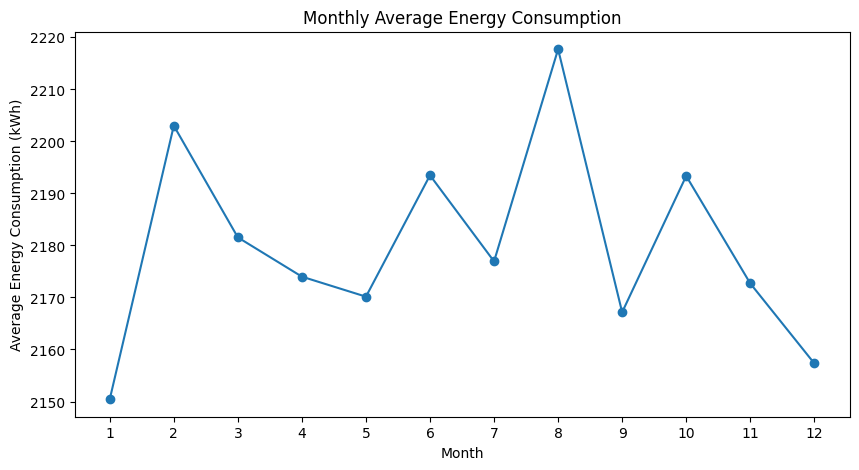

In [167]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o"
)

plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average Energy Consumption (kWh)")

plt.xticks(range(1, 13))

plt.show()

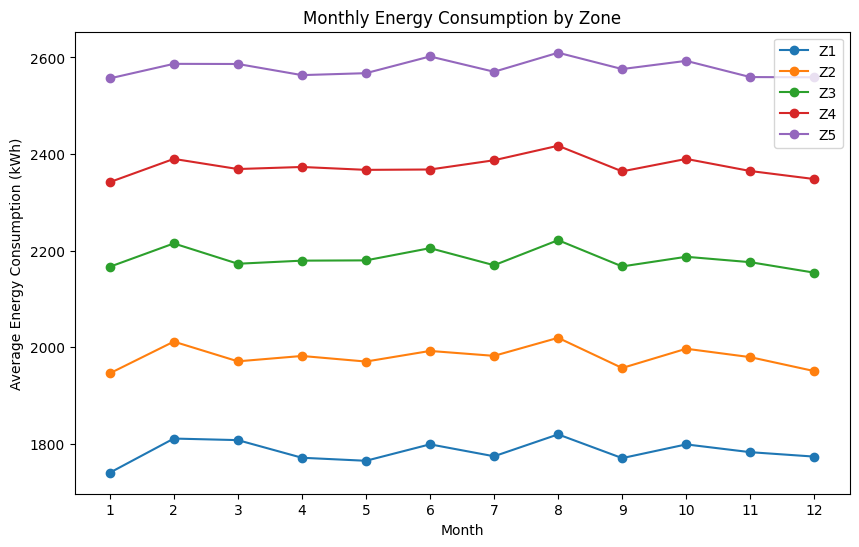

In [169]:
plt.figure(figsize=(10, 6))

for zone in zones:

    zone_data = monthly_zone[
        monthly_zone["ZoneID"] == zone
    ]

    plt.plot(
        zone_data["Month"],
        zone_data["EnergyConsumption"],
        marker="o",
        label=zone
    )

plt.title("Monthly Energy Consumption by Zone")
plt.xlabel("Month")
plt.ylabel("Average Energy Consumption (kWh)")

plt.xticks(range(1, 13))
plt.legend()

plt.show()

In [170]:
import seaborn as sns

In [ ]:
### Correlation Heatmap

In [171]:
correlation = df[
    [
        "AvgTemperature",
        "Humidity",
        "SpecialEvent",
        "EnergyConsumption"
    ]
].corr()

correlation

,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
AvgTemperature,1.000000,0.030941,0.030655,0.273726
Humidity,0.030941,1.000000,-0.014855,0.100645
SpecialEvent,0.030655,-0.014855,1.000000,0.203435
EnergyConsumption,0.273726,0.100645,0.203435,1.000000


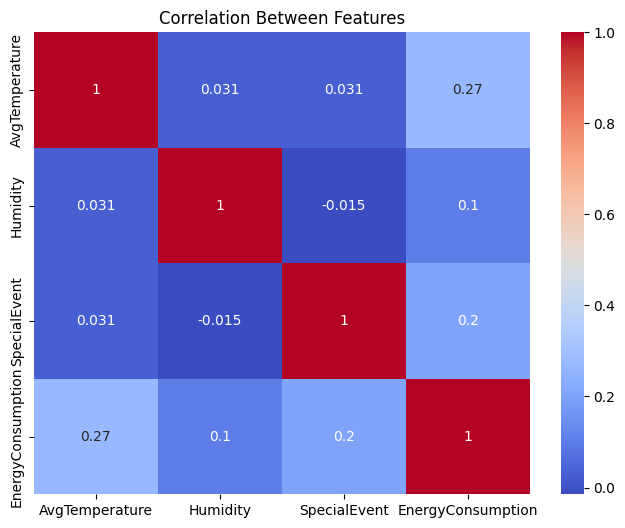

In [172]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Features")

plt.show()

In [ ]:
### Event VS Non event Energy Consumption

In [173]:
event_average

,EnergyConsumption
SpecialEvent,
0,2158.505199
1,2361.736842


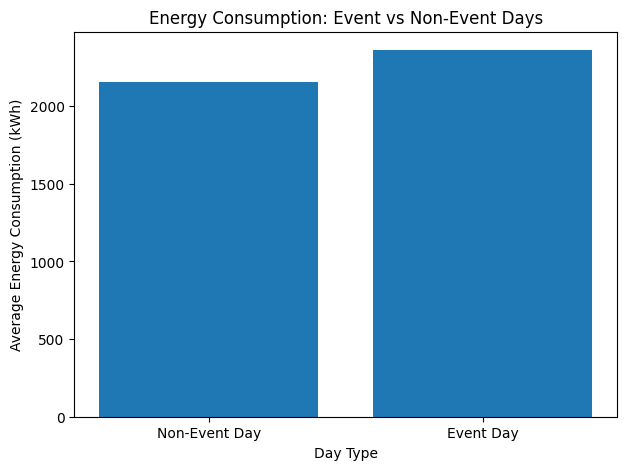

In [174]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Event Day", "Event Day"],
    [
        event_average[0],
        event_average[1]
    ]
)

plt.title("Energy Consumption: Event vs Non-Event Days")
plt.xlabel("Day Type")
plt.ylabel("Average Energy Consumption (kWh)")

plt.show()

In [175]:
special_event * 200

np.int64(0)

In [ ]:
## Machine Learning Model

In [176]:
df["ZoneNumber"] = df["ZoneID"].str.replace("Z", "").astype(int)

In [177]:
df[["ZoneID", "ZoneNumber"]].head(10)

,ZoneID,ZoneNumber
0,Z1,1
1,Z2,2
2,Z3,3
3,Z4,4
4,Z5,5
5,Z1,1
6,Z2,2
7,Z3,3
8,Z4,4
9,Z5,5


In [178]:
X = df[
    [
        "ZoneNumber",
        "AvgTemperature",
        "Humidity",
        "SpecialEvent"
    ]
]

y = df["EnergyConsumption"]

In [179]:
X.head()

,ZoneNumber,AvgTemperature,Humidity,SpecialEvent
0,1,28,40,0
1,2,28,40,0
2,3,28,40,0
3,4,28,40,0
4,5,28,40,0


In [180]:
y.head()

,EnergyConsumption
0,1757
1,1865
2,2163
3,2229
4,2534


In [181]:
from sklearn.model_selection import train_test_split

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [183]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1460
Testing rows: 365


In [184]:
from sklearn.linear_model import LinearRegression

In [185]:
model = LinearRegression()

In [186]:
model.fit(X_train, y_train)

LinearRegression()

In [187]:
y_pred = model.predict(X_test)

In [188]:
print("Actual:")
print(y_test.head())

print("\nPredicted:")
print(y_pred[:5])

Actual:
555     1895
1744    2545
297     2279
733     2542
910     1641
Name: EnergyConsumption, dtype: int64

Predicted:
[1860.40378031 2535.58967676 2327.69806059 2445.07170462 1660.1791485 ]


In [189]:
from sklearn.metrics import mean_absolute_error

In [190]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 49.453780518478446


In [191]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
555,1895,1860.403780
1744,2545,2535.589677
297,2279,2327.698061
733,2542,2445.071705
910,1641,1660.179148
629,2577,2614.083758
1034,2577,2477.138908
609,2492,2499.449658
678,2241,2333.928685
602,2339,2265.041299


In [192]:
new_data = pd.DataFrame({
    "ZoneNumber": [3],
    "AvgTemperature": [32],
    "Humidity": [70],
    "SpecialEvent": [1]
})

In [193]:
prediction = model.predict(new_data)

print("Predicted Energy Consumption:", prediction[0], "kWh")

Predicted Energy Consumption: 2420.4074391051863 kWh


In [ ]:
## Next-Day Energy Prediction

In [194]:
df = df.sort_values(["ZoneID", "Date"])

In [195]:
df["NextDayEnergy"] = df.groupby("ZoneID")["EnergyConsumption"].shift(-1)

In [196]:
df[
    ["Date", "ZoneID", "EnergyConsumption", "NextDayEnergy"]
].head(10)

,Date,ZoneID,EnergyConsumption,NextDayEnergy
0,2025-01-01,Z1,1757,1614.0
5,2025-01-02,Z1,1614,1757.0
10,2025-01-03,Z1,1757,2057.0
15,2025-01-04,Z1,2057,1844.0
20,2025-01-05,Z1,1844,1655.0
25,2025-01-06,Z1,1655,1843.0
30,2025-01-07,Z1,1843,1702.0
35,2025-01-08,Z1,1702,1782.0
40,2025-01-09,Z1,1782,1641.0
45,2025-01-10,Z1,1641,1830.0


In [197]:
df["NextDayEnergy"].isnull().sum()

np.int64(5)

In [198]:
df_model = df.dropna(subset=["NextDayEnergy"]).copy()

In [199]:
df_model.shape

(1820, 9)

In [200]:
df["NextTemp"] = df.groupby("ZoneID")["AvgTemperature"].shift(-1)

df["NextHumidity"] = df.groupby("ZoneID")["Humidity"].shift(-1)

df["NextEvent"] = df.groupby("ZoneID")["SpecialEvent"].shift(-1)

In [201]:
df_model = df.dropna(
    subset=[
        "NextDayEnergy",
        "NextTemp",
        "NextHumidity",
        "NextEvent"
    ]
).copy()

In [202]:
X = df_model[
    [
        "ZoneNumber",
        "NextTemp",
        "NextHumidity",
        "NextEvent"
    ]
]

In [203]:
y = df_model["NextDayEnergy"]

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [205]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [206]:
y_pred = model.predict(X_test)

In [207]:
mae = mean_absolute_error(y_test, y_pred)

print("Next-Day Model MAE:", round(mae, 2), "kWh")

Next-Day Model MAE: 51.75 kWh


In [208]:
zone = int(input("Enter Zone Number (1-5): "))

temperature = float(
    input("Enter tomorrow's temperature (°C): ")
)

humidity = float(
    input("Enter tomorrow's humidity (%): ")
)

event = int(
    input("Special Event tomorrow? (0 = No, 1 = Yes): ")
)

Enter Zone Number (1-5): 4
Enter tomorrow's temperature (°C): 35
Enter tomorrow's humidity (%): 66
Special Event tomorrow? (0 = No, 1 = Yes): 1


In [209]:
user_data = pd.DataFrame({
    "ZoneNumber": [zone],
    "NextTemp": [temperature],
    "NextHumidity": [humidity],
    "NextEvent": [event]
})

In [210]:
prediction = model.predict(user_data)

print(
    "Predicted Tomorrow's Energy Consumption:",
    round(prediction[0], 2),
    "kWh"
)

Predicted Tomorrow's Energy Consumption: 2655.3 kWh


In [211]:
def predict_energy():

    try:
        zone = int(input("Enter Zone Number (1-5): "))
        temperature = float(input("Enter tomorrow's temperature (°C): "))
        humidity = float(input("Enter tomorrow's humidity (%): "))
        event = int(input("Special Event tomorrow? (0 = No, 1 = Yes): "))

        # Input validation
        if zone < 1 or zone > 5:
            print("Invalid Zone! Please enter a number between 1 and 5.")
            return

        if temperature < -10 or temperature > 55:
            print("Invalid Temperature! Please enter a realistic value.")
            return

        if humidity < 0 or humidity > 100:
            print("Invalid Humidity! Please enter a value between 0 and 100.")
            return

        if event not in [0, 1]:
            print("Invalid Event! Enter only 0 or 1.")
            return

        user_data = pd.DataFrame({
            "ZoneNumber": [zone],
            "NextTemp": [temperature],
            "NextHumidity": [humidity],
            "NextEvent": [event]
        })

        prediction = model.predict(user_data)

        print(
            "\nPredicted Tomorrow's Energy Consumption:",
            round(prediction[0], 2),
            "kWh"
        )

    except ValueError:
        print("\nInvalid input! Please enter numbers only.")

In [212]:
predict_energy()

Enter Zone Number (1-5): 2
Enter tomorrow's temperature (°C): 45
Enter tomorrow's humidity (%): 35
Special Event tomorrow? (0 = No, 1 = Yes): 1

Predicted Tomorrow's Energy Consumption: 2350.74 kWh


In [213]:
try:
    # Code that might raise an exception
    pass
except ValueError:
    # Handle the ValueError
    print("A ValueError occurred!")

In [214]:
print("Total Records:", len(df))
print("Total Zones:", df["ZoneID"].nunique())
print("Total Days:", df["Date"].nunique())
print("Model MAE:", round(mae, 2), "kWh")

Total Records: 1825
Total Zones: 5
Total Days: 365
Model MAE: 51.75 kWh


In [218]:
## Conclusion
This project analyzed electricity consumption across five city zones using a synthetic dataset of 365 days.
The analysis showed that energy consumption varies across zones and generally increases on special-event days.
Temperature and humidity also influence electricity demand.
A Linear Regression model was developed to predict next-day energy consumption using zone, temperature, humidity, and event information.
The model was evaluated using Mean Absolute Error (MAE).
Finally, an interactive prediction system with input validation was developed.